# **Data preparation for training**

Investigate dataset and prepare the dataset for binary classification.

# **Import the required libraries**

In [1]:
import pandas
import numpy
import seaborn
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Just for clearing the outputs, removing Python warnings.
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

# **Load the raw dataset**

In [3]:
# Diabetes dataset from Kaggle
# https://www.kaggle.com/datasets/mathchi/diabetes-data-set

original_data: pandas.DataFrame = pandas.read_csv("diabetes.csv")
original_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
print("Null values count:")
print(original_data.isnull().sum())

Null values count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
print("Is there any duplications:")
print(original_data.duplicated().any())

Is there any duplications:
False


# **Investigate the target variable**

Target label samples count:
Outcome
0    500
1    268
Name: count, dtype: int64
Target label No Diabates percentage:: 65.1%
Target label Diabetes percentage: 34.9%


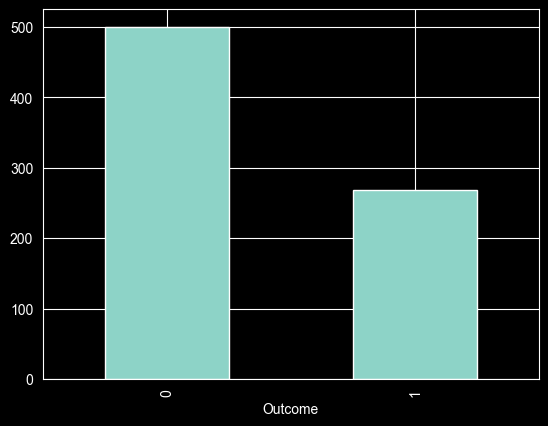

In [7]:
outcome_values: pandas.Series = original_data["Outcome"].value_counts()
outcome_values.plot(kind="bar")

print("Target label samples count:")
print(original_data["Outcome"].value_counts())

print(f"Target label No Diabates percentage:: {round(outcome_values[0] / original_data['Outcome'].count() * 100, 2)}%")
print(f"Target label Diabetes percentage: {round(outcome_values[1] / original_data['Outcome'].count() * 100, 2)}%")

# **Investigate independendent variables (features)**

In [8]:
def diagnostic_plots(df, variable, target, save):
    plt.figure(figsize=(20, 7))

    # histogram
    plt.subplot(1, 4, 1)
    seaborn.histplot(df[variable], kde = True, color='r')
    plt.title('Histogram')

    # scatterplot
    plt.subplot(1, 4, 2)
    plt.scatter(df[variable], df[target], color = 'g')
    plt.title('Scatterplot')

    # boxplot
    plt.subplot(1, 4, 3)
    seaborn.boxplot(y=df[variable], color = 'b')
    plt.title('Boxplot')

    # barplot
    plt.subplot(1, 4, 4)
    seaborn.barplot(x = target, y = variable, data = df)
    plt.title('Barplot')

    if save:
      plt.savefig(variable + ".pdf")
    plt.show()

In [9]:
original_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


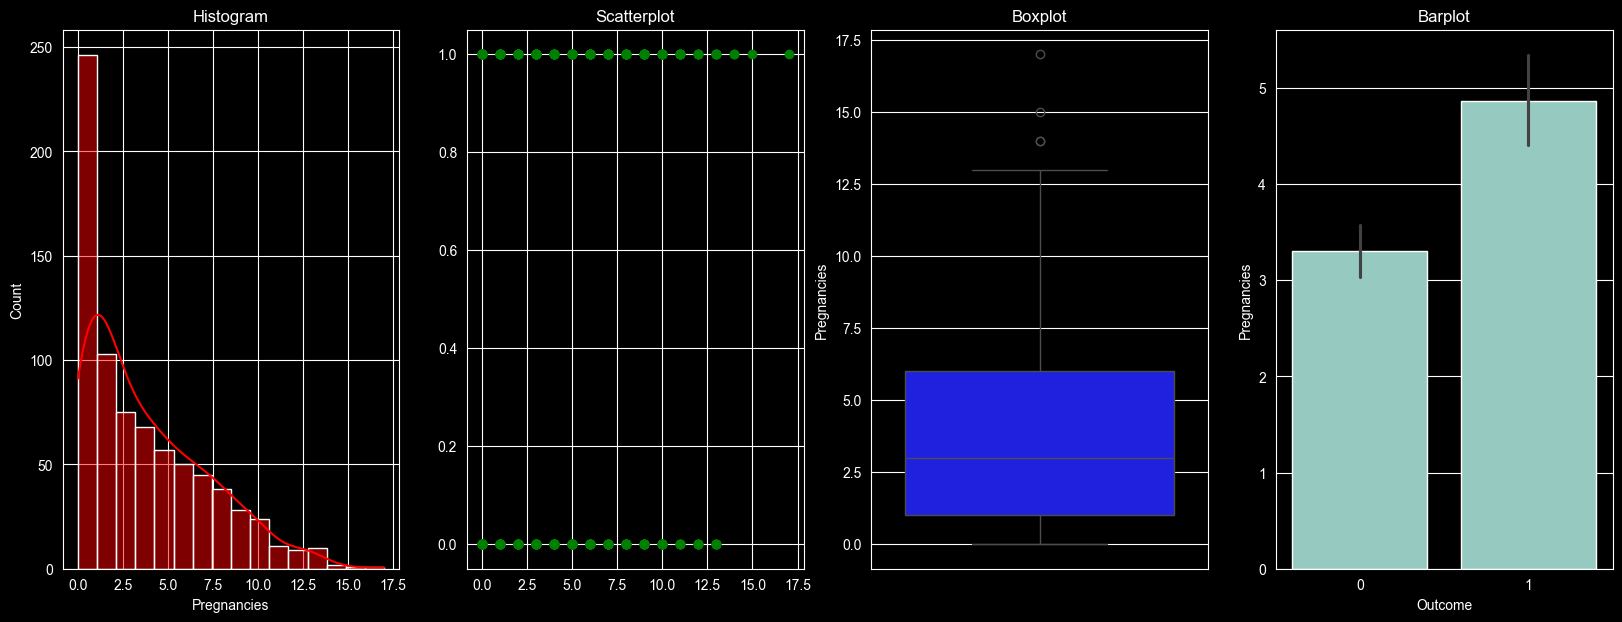

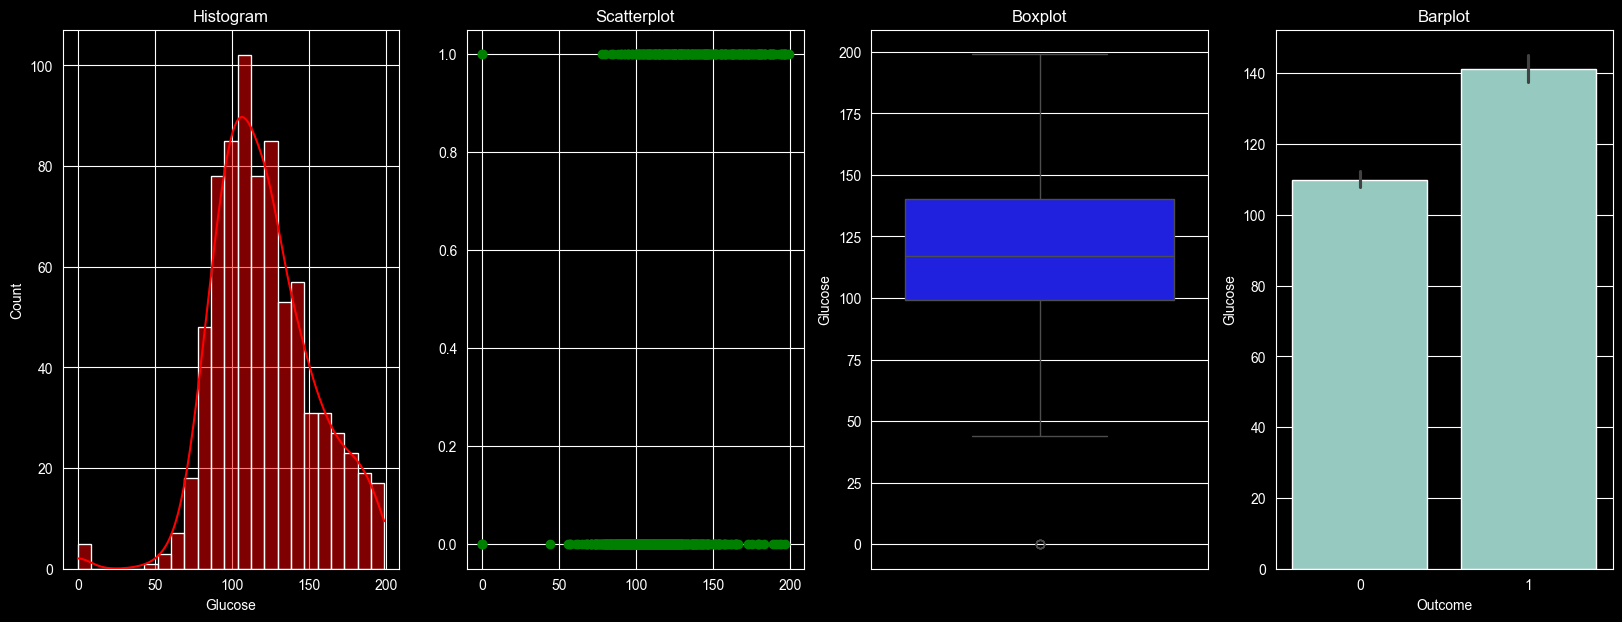

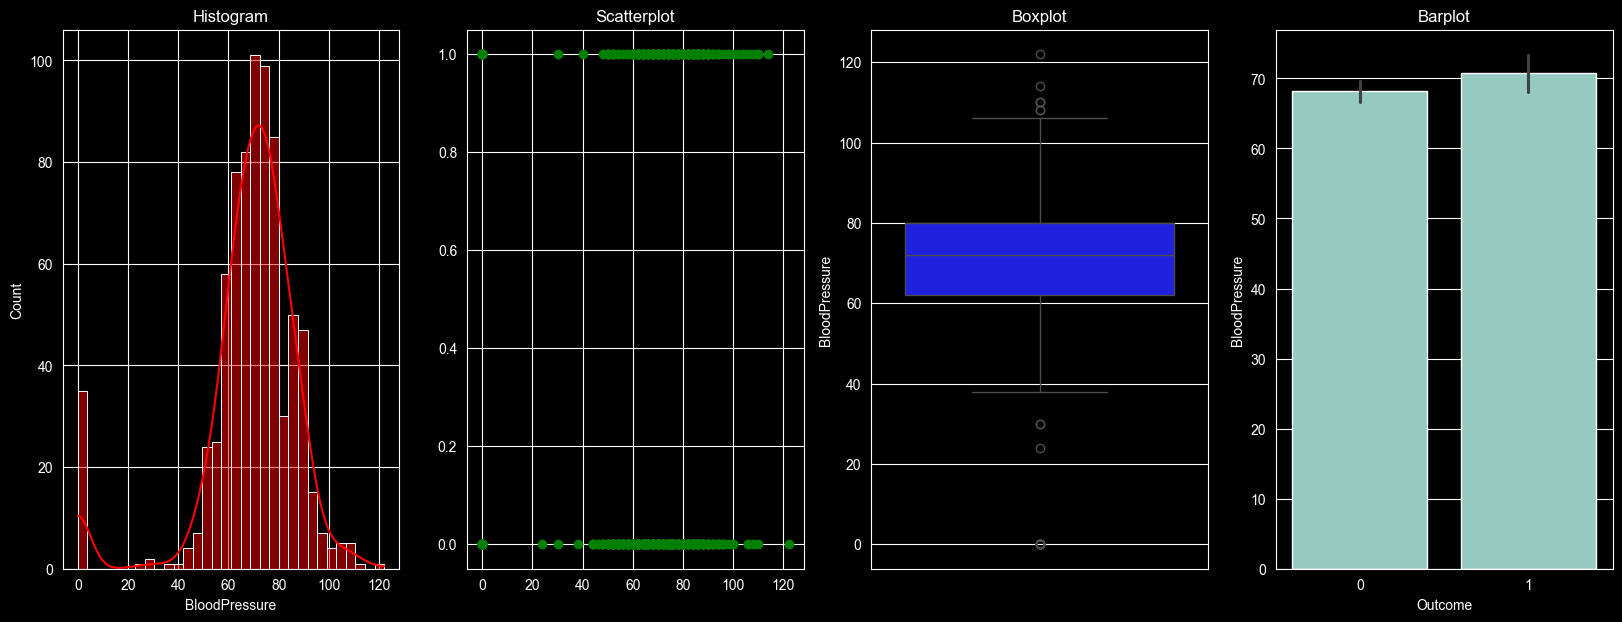

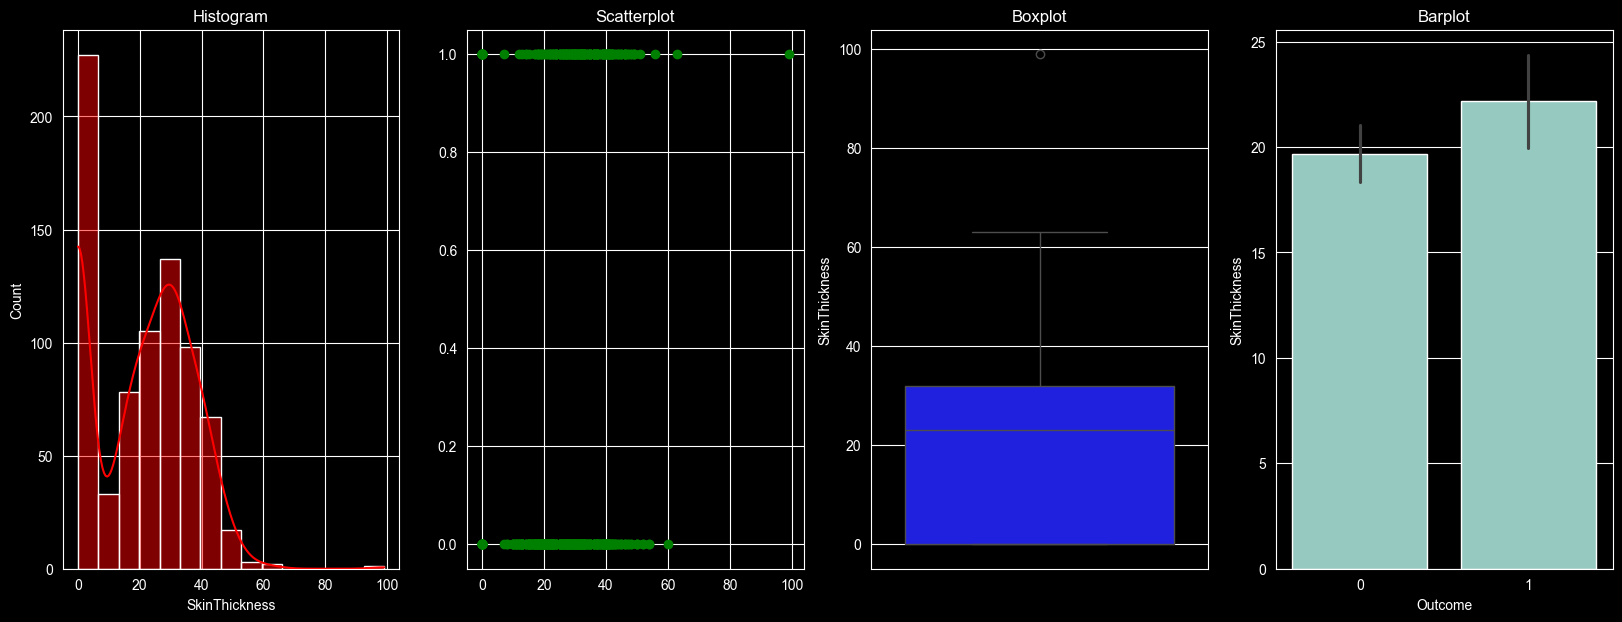

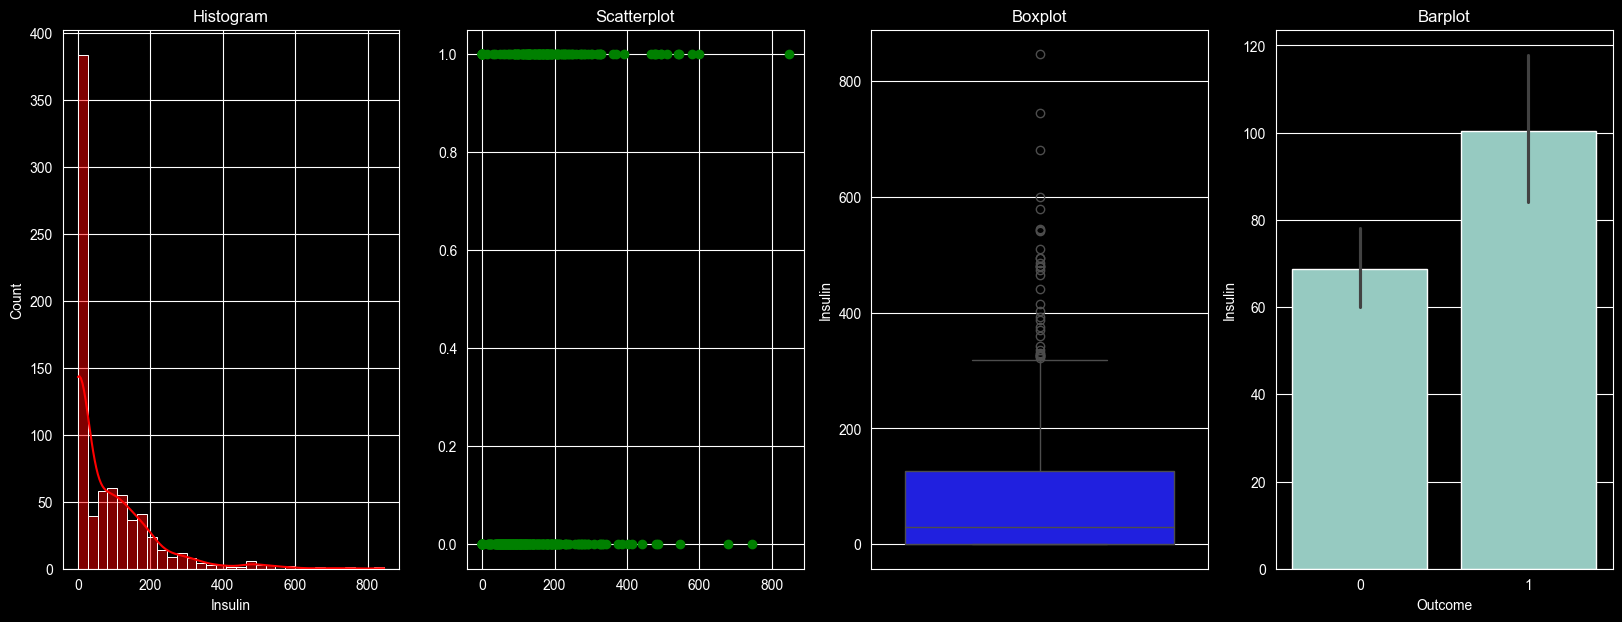

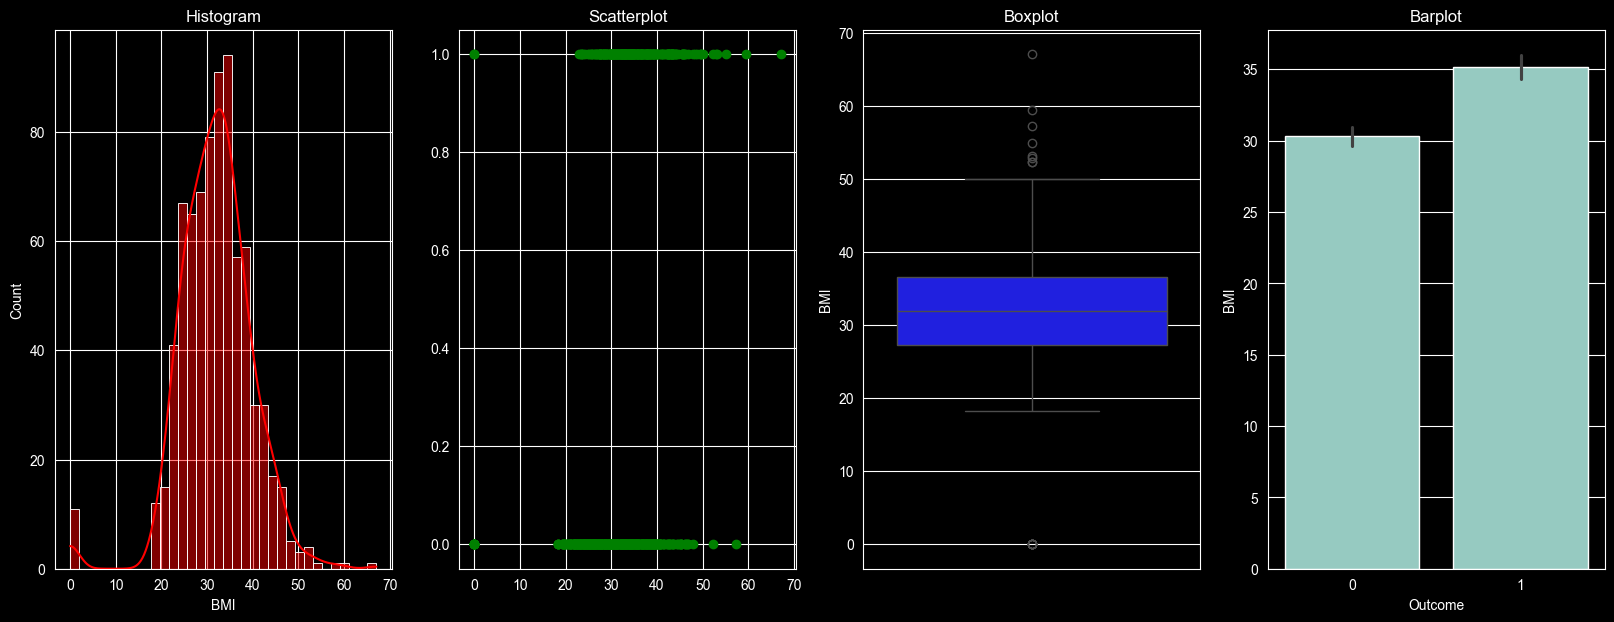

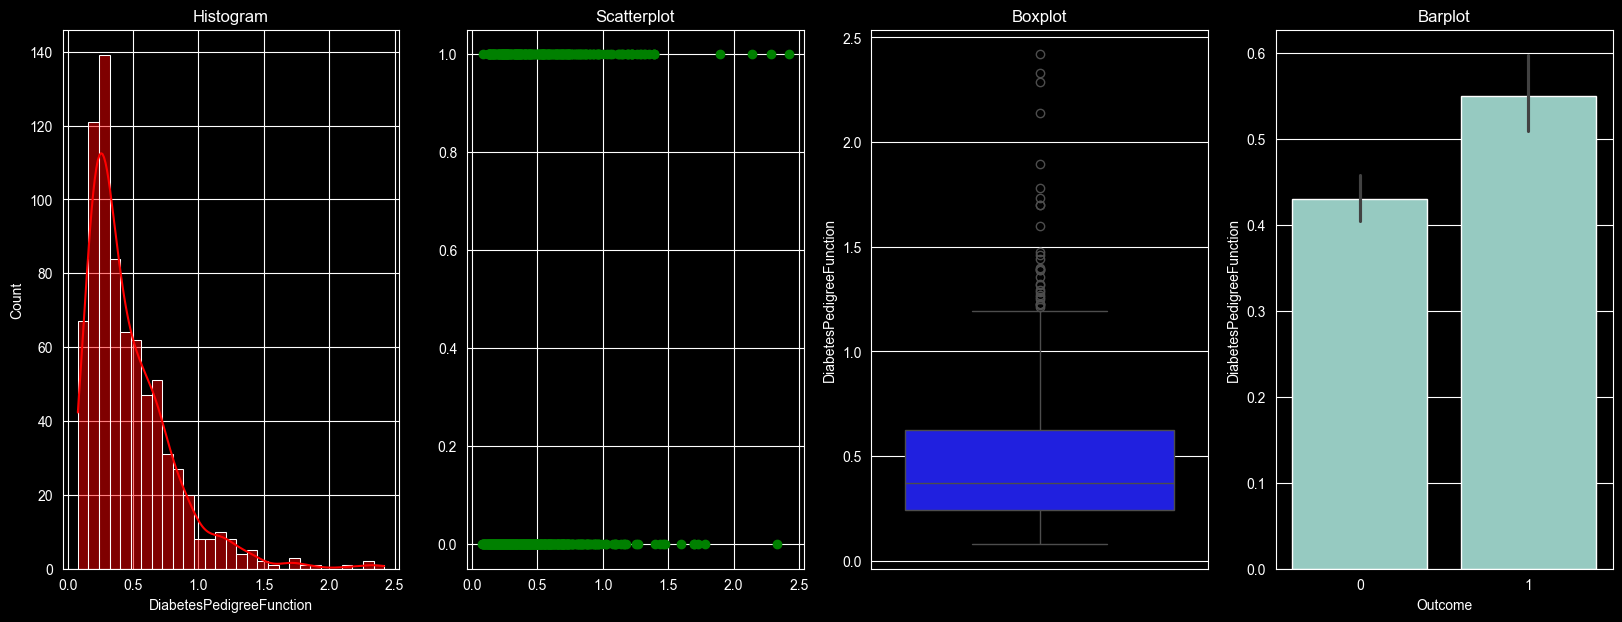

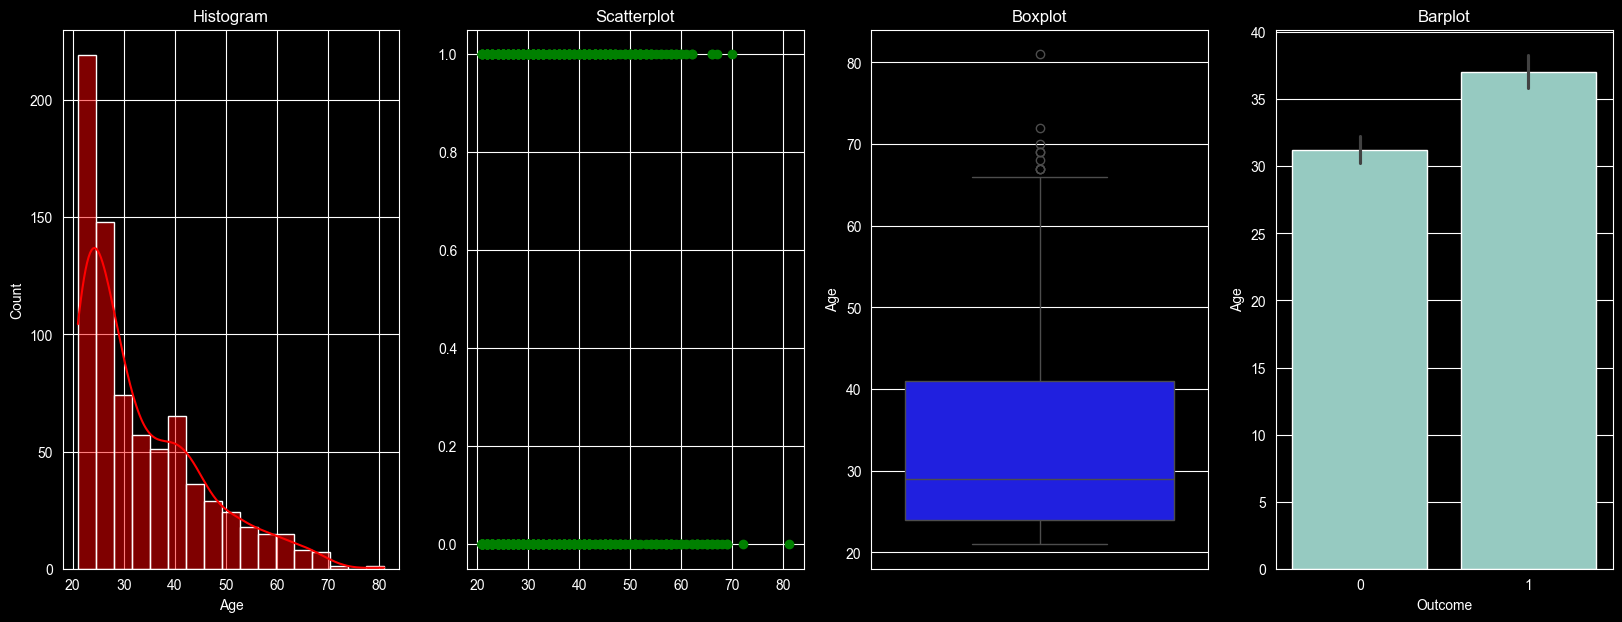

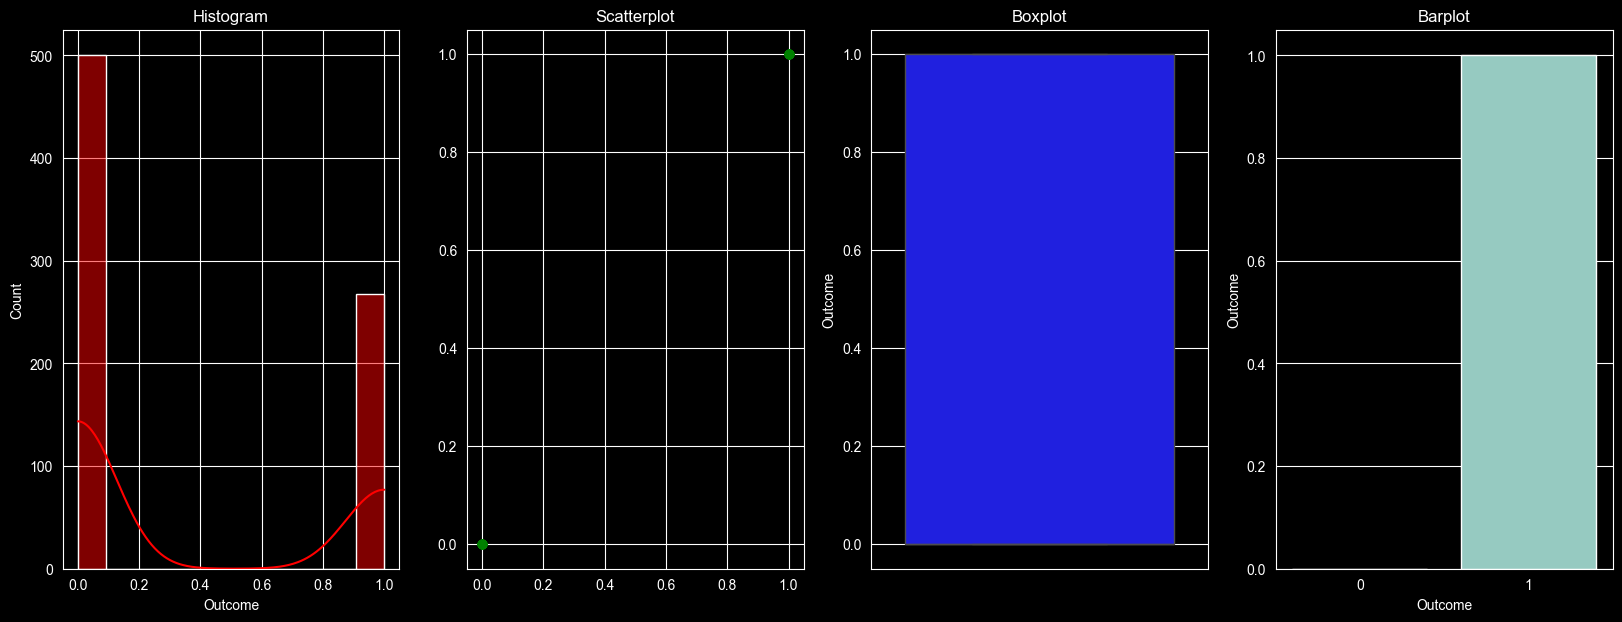

In [10]:
for column in original_data:
  diagnostic_plots(original_data, column, "Outcome", False)

## **Modify the dataset**

In [11]:
modified_data = original_data.copy()

In [12]:
# Replace the median value for those columns where the actual value can't be zero or less then zero.
for column in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    median = modified_data[column].median()
    modified_data.loc[modified_data[column] <= 0, column] = median

In [13]:
# Turn the features' which have exponential like deviation into normal like deviation
constant: float = 1.0

modified_data["ln_pregnancies"] = numpy.log(modified_data["Pregnancies"] + constant)
modified_data["ln_insulin"] = numpy.log(modified_data["Insulin"] + constant)
modified_data["ln_age"] = numpy.log(modified_data["Age"] + constant)
modified_data["ln_diabetes_pedigree_function"] = numpy.log(modified_data["DiabetesPedigreeFunction"] + constant)

modified_data[["ln_pregnancies", "ln_insulin", "ln_age", "ln_diabetes_pedigree_function"]].fillna(modified_data[["ln_pregnancies", "ln_insulin", "ln_age", "ln_diabetes_pedigree_function"]].mean(), inplace=True)

modified_data[["ln_pregnancies", "ln_insulin", "ln_age", "ln_diabetes_pedigree_function"]].head()

,ln_pregnancies,ln_insulin,ln_age,ln_diabetes_pedigree_function
0,1.945910,3.449988,3.931826,0.486738
1,0.693147,3.449988,3.465736,0.300845
2,2.197225,3.449988,3.496508,0.514021
3,0.693147,4.553877,3.091042,0.154436
4,0.000000,5.129899,3.526361,1.190279


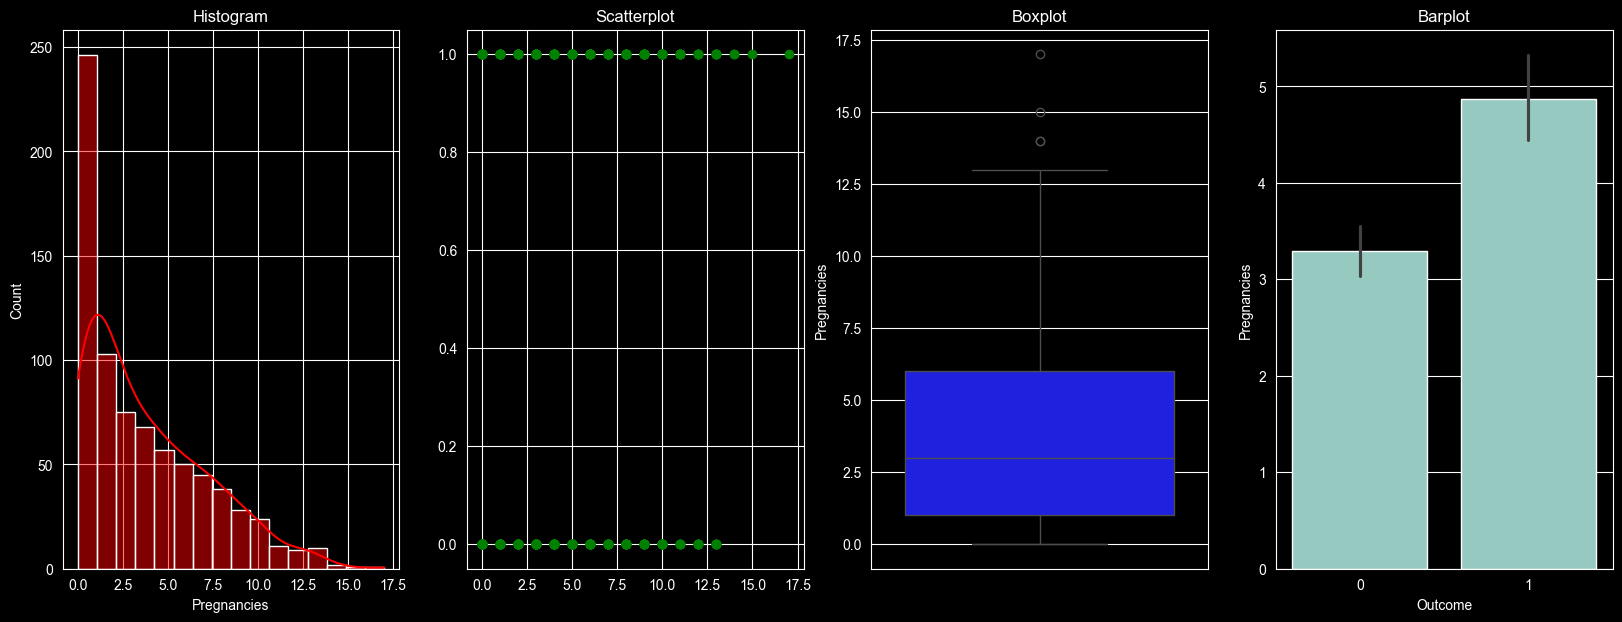

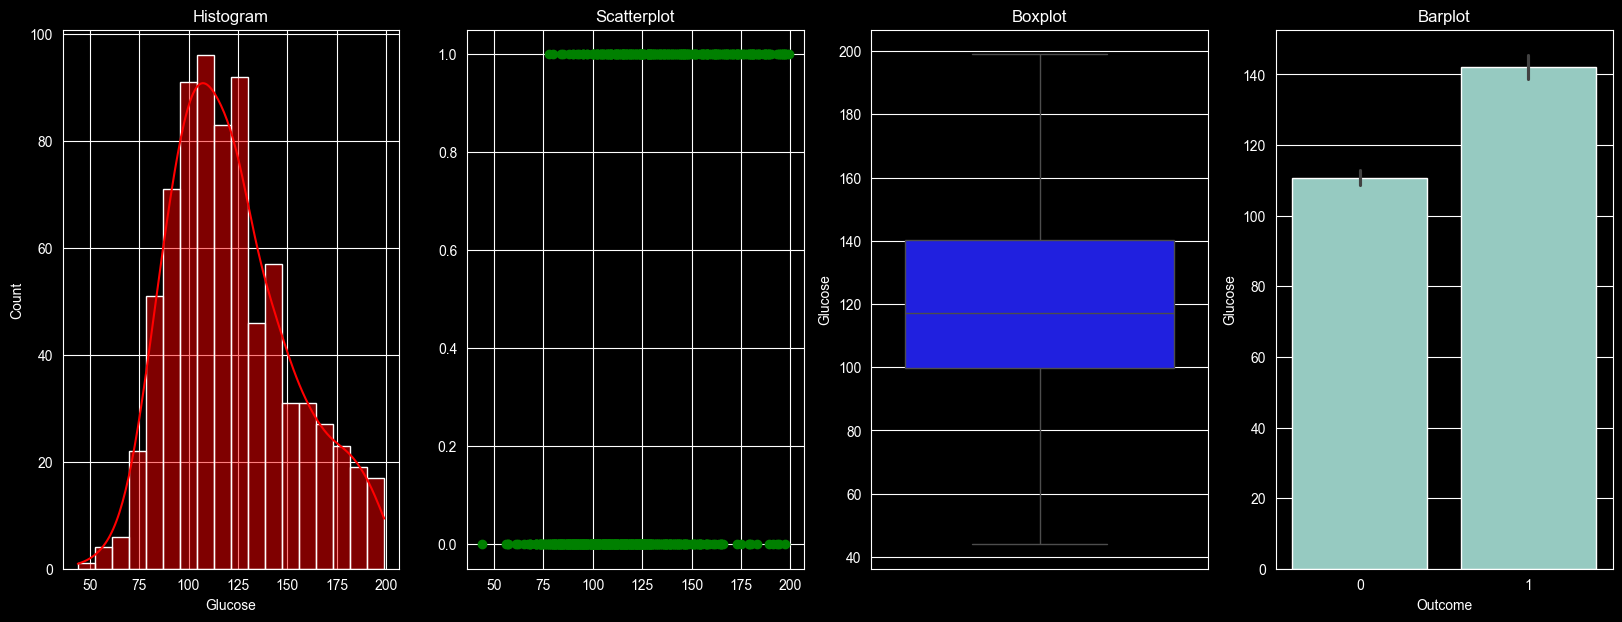

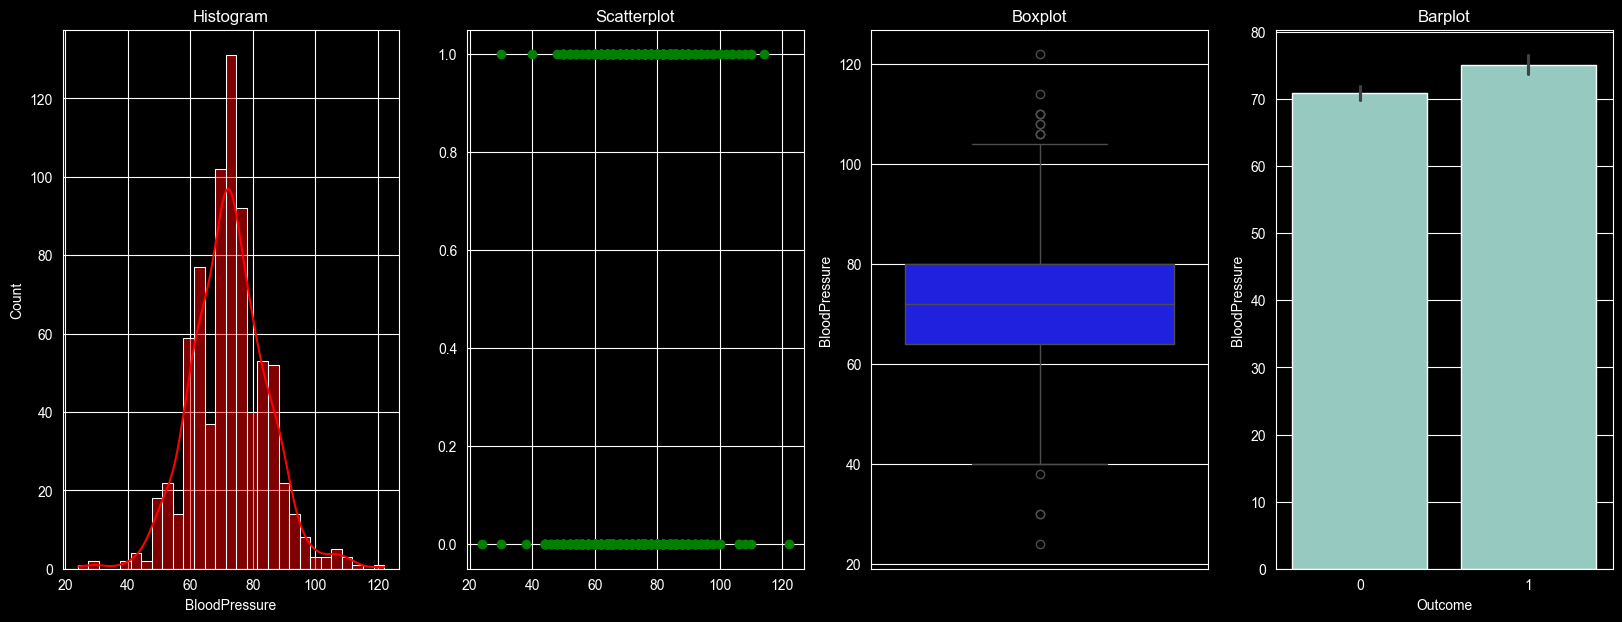

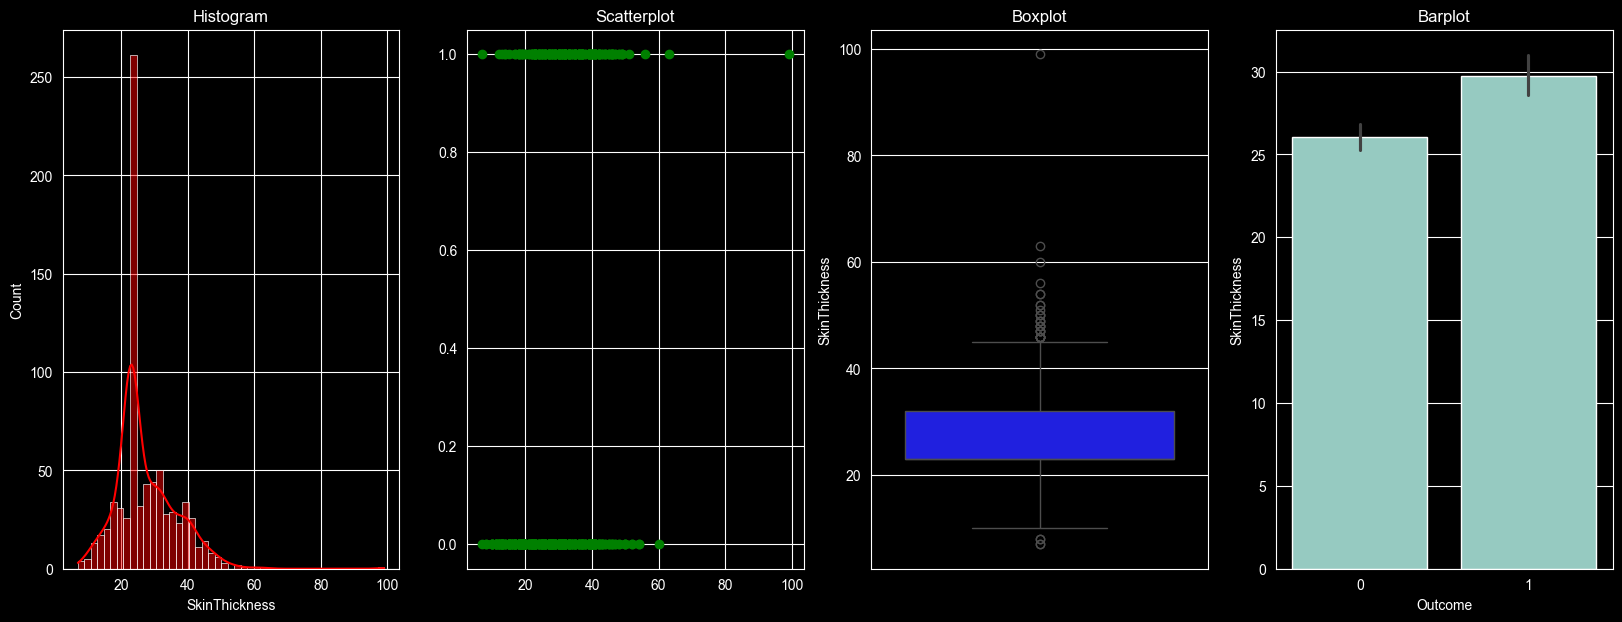

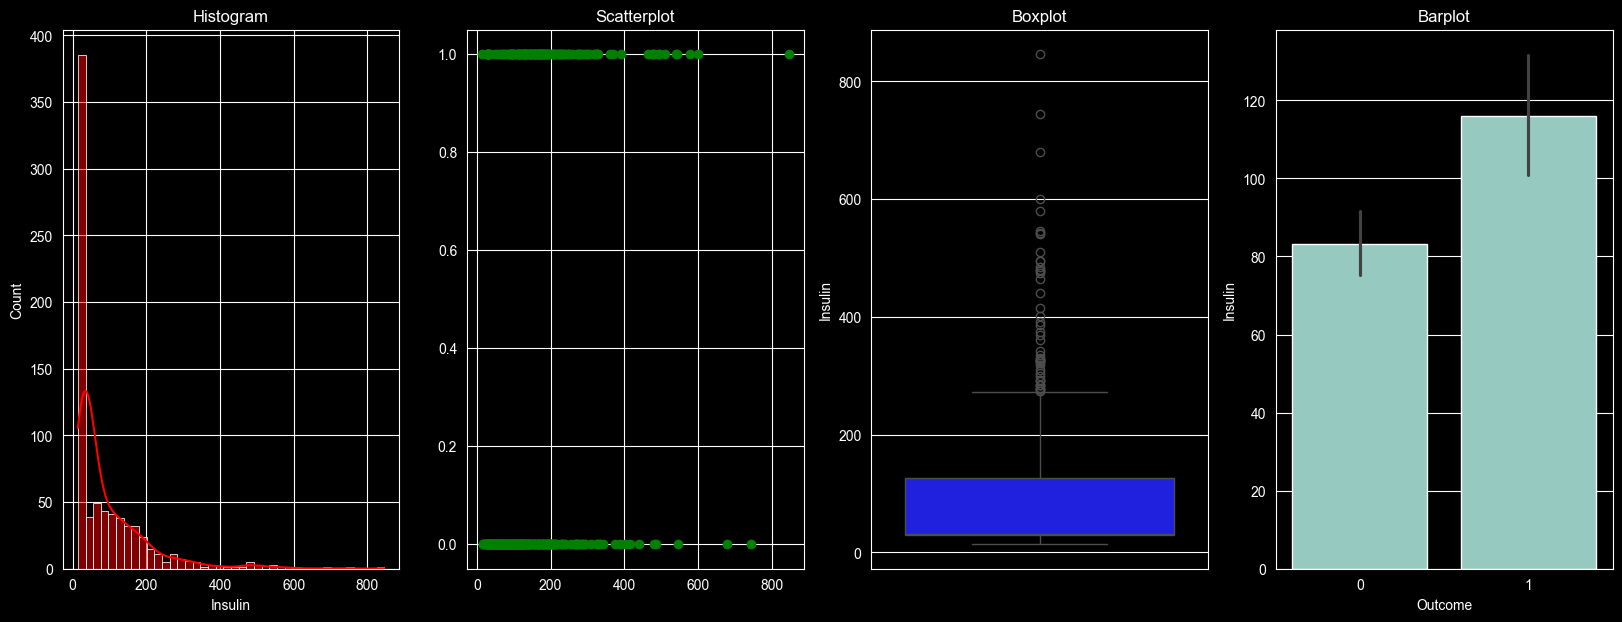

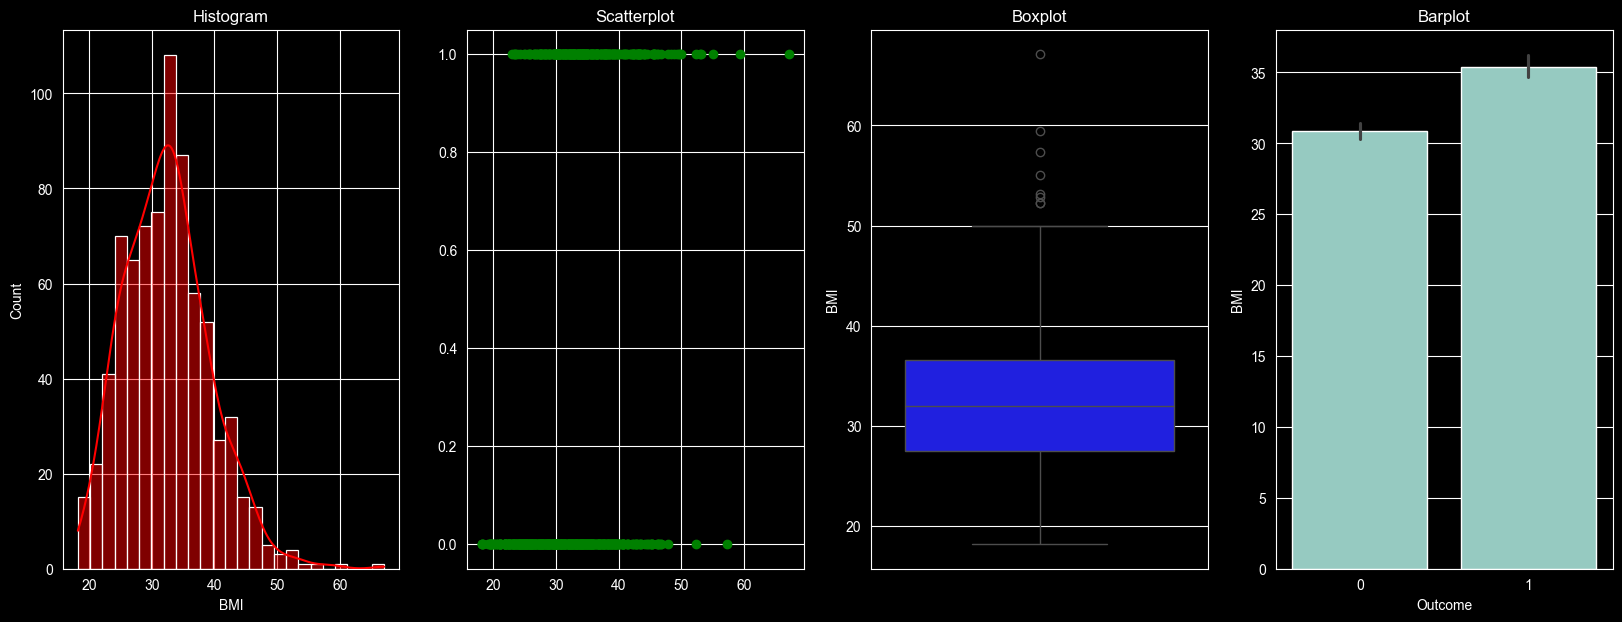

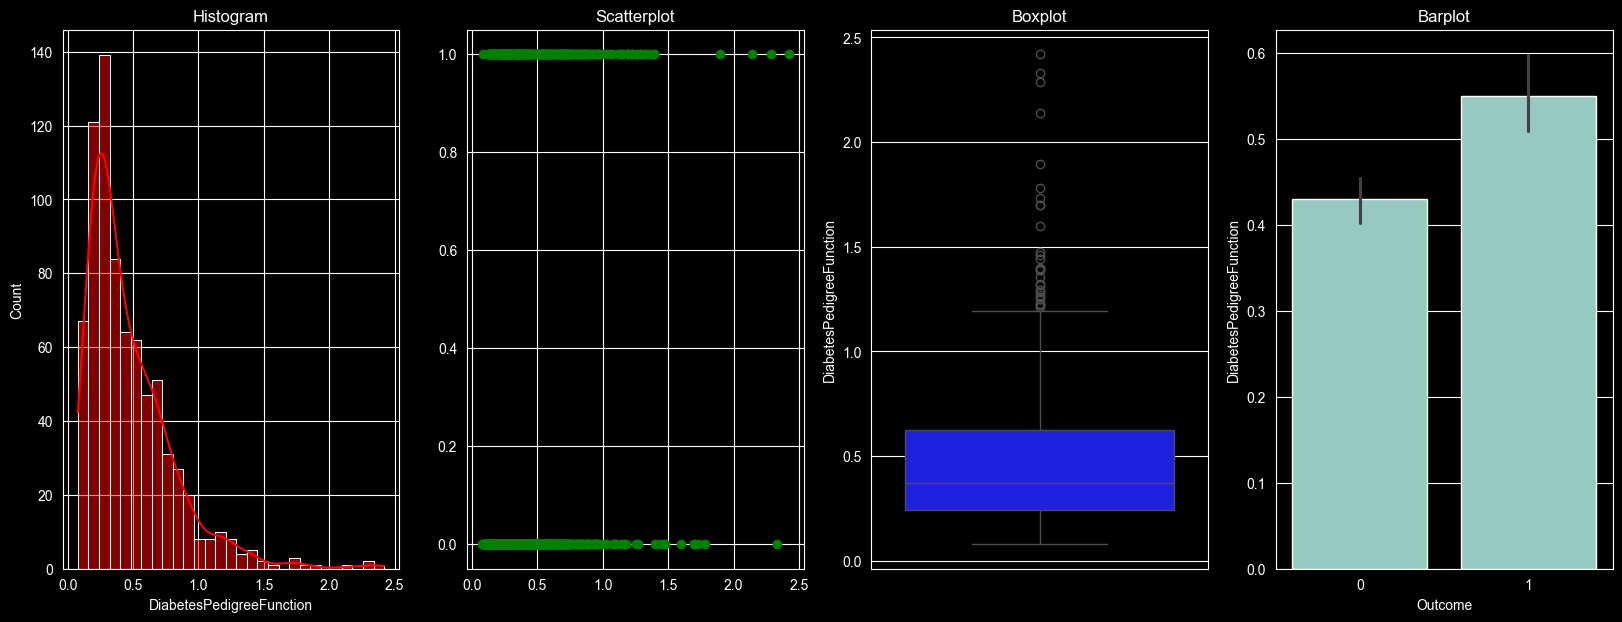

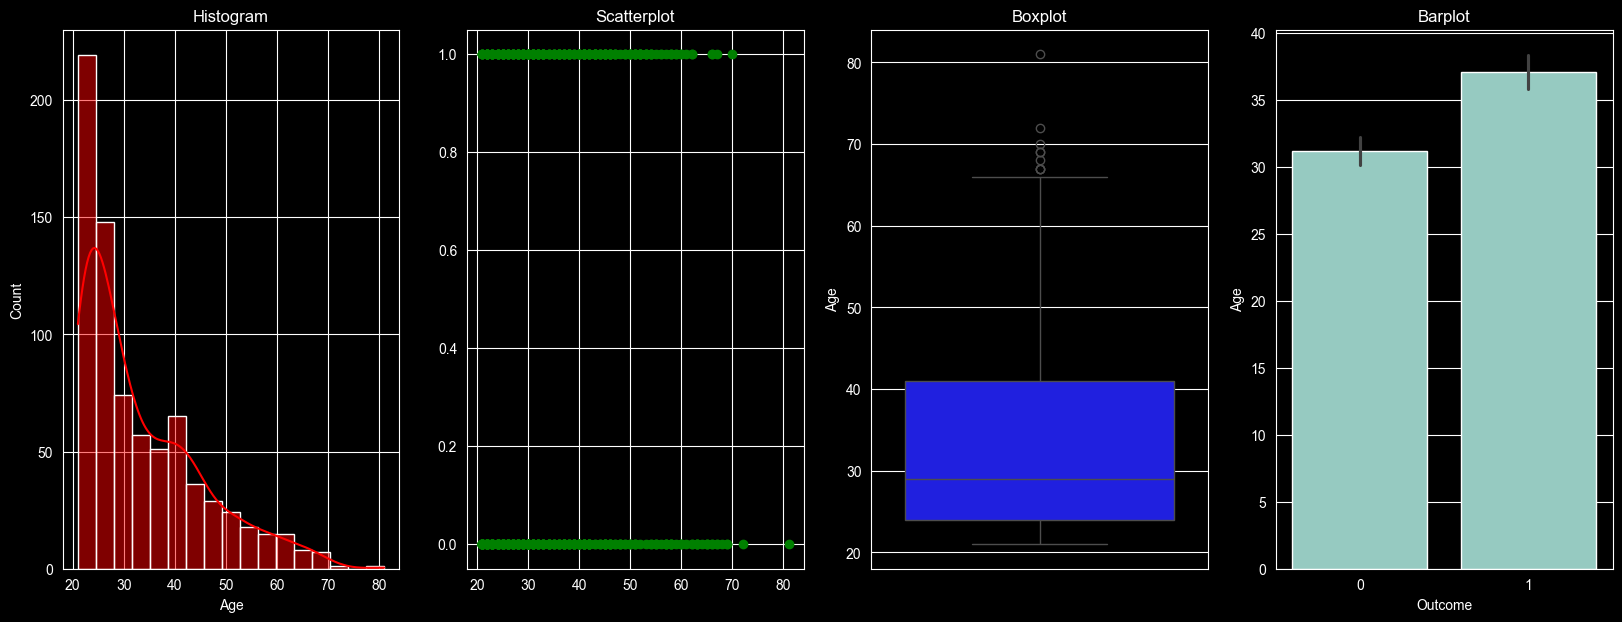

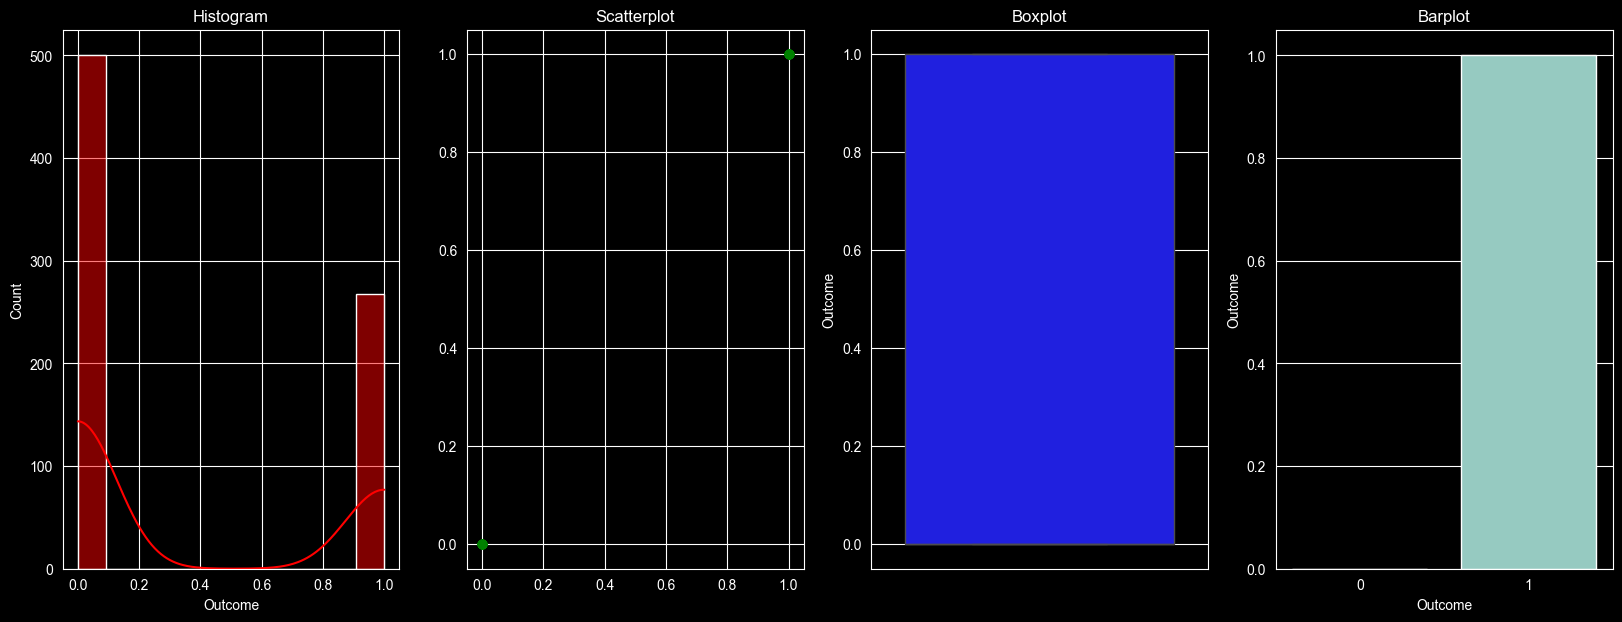

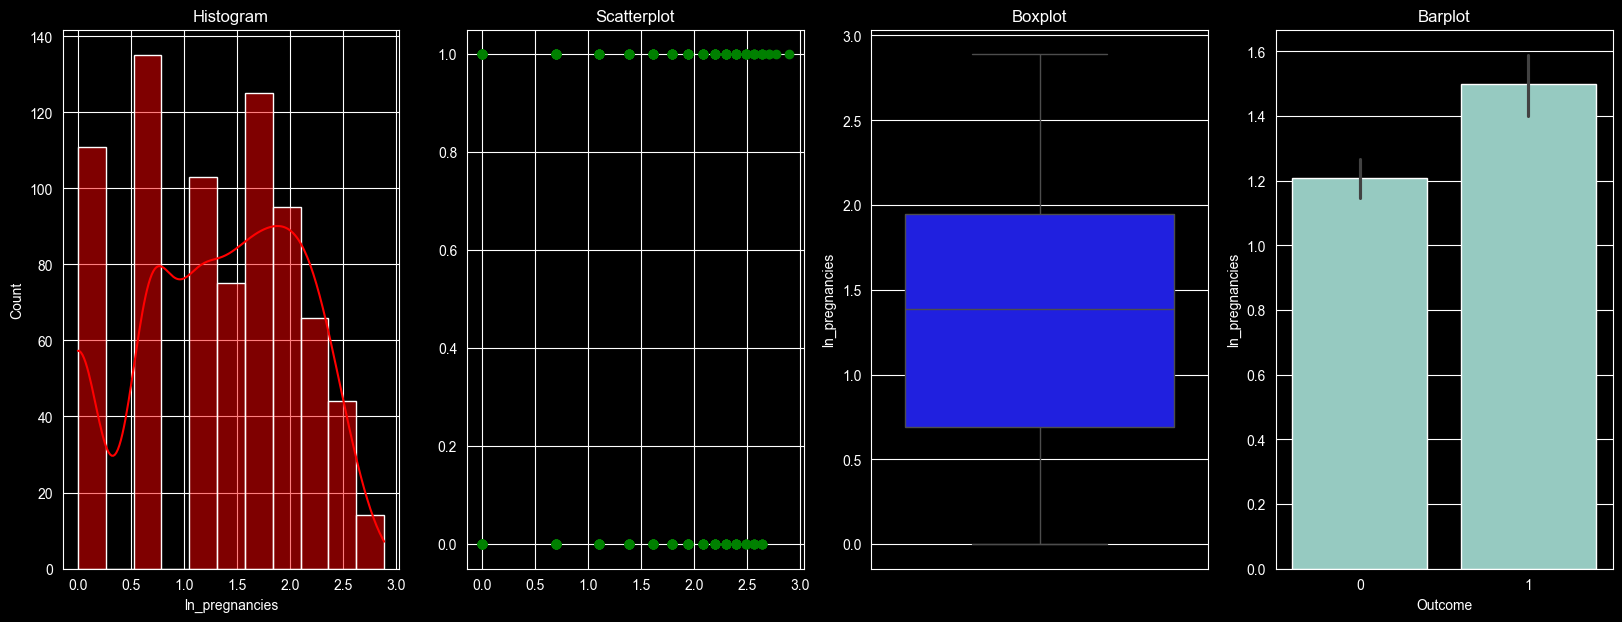

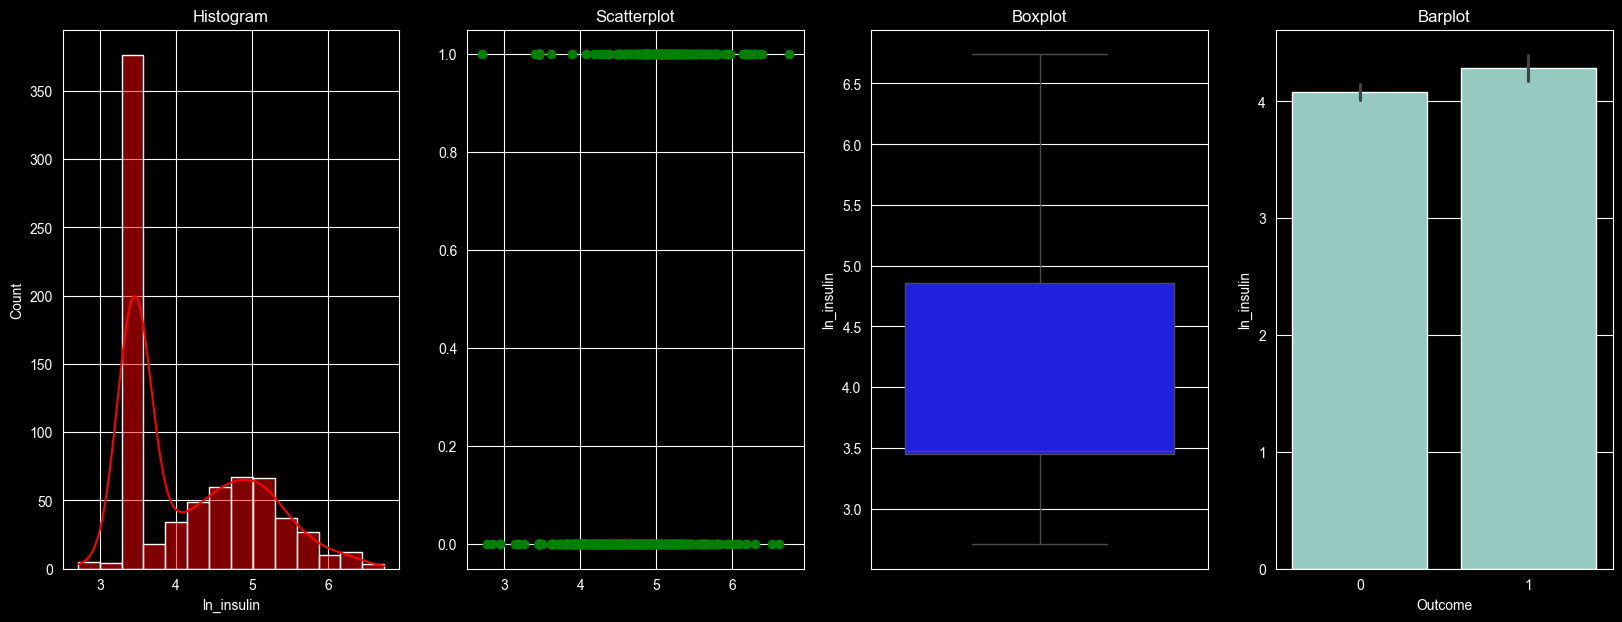

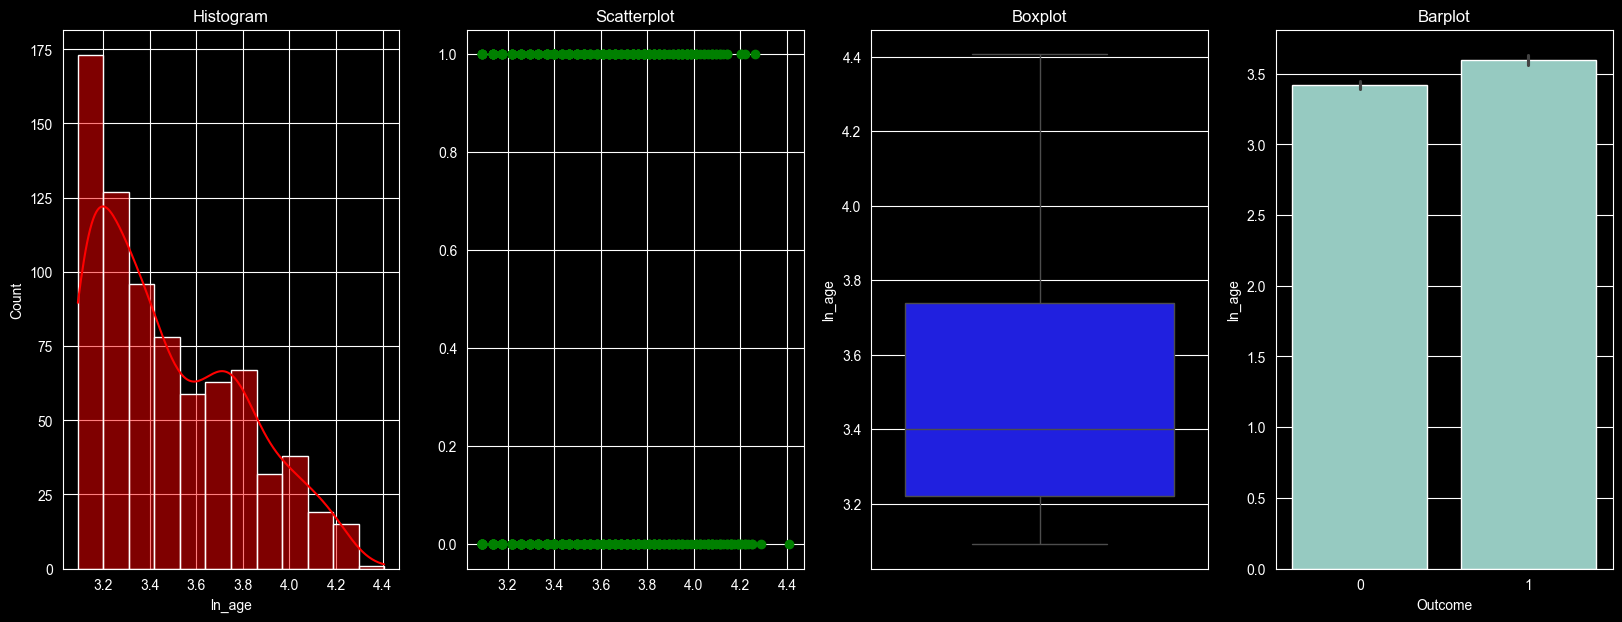

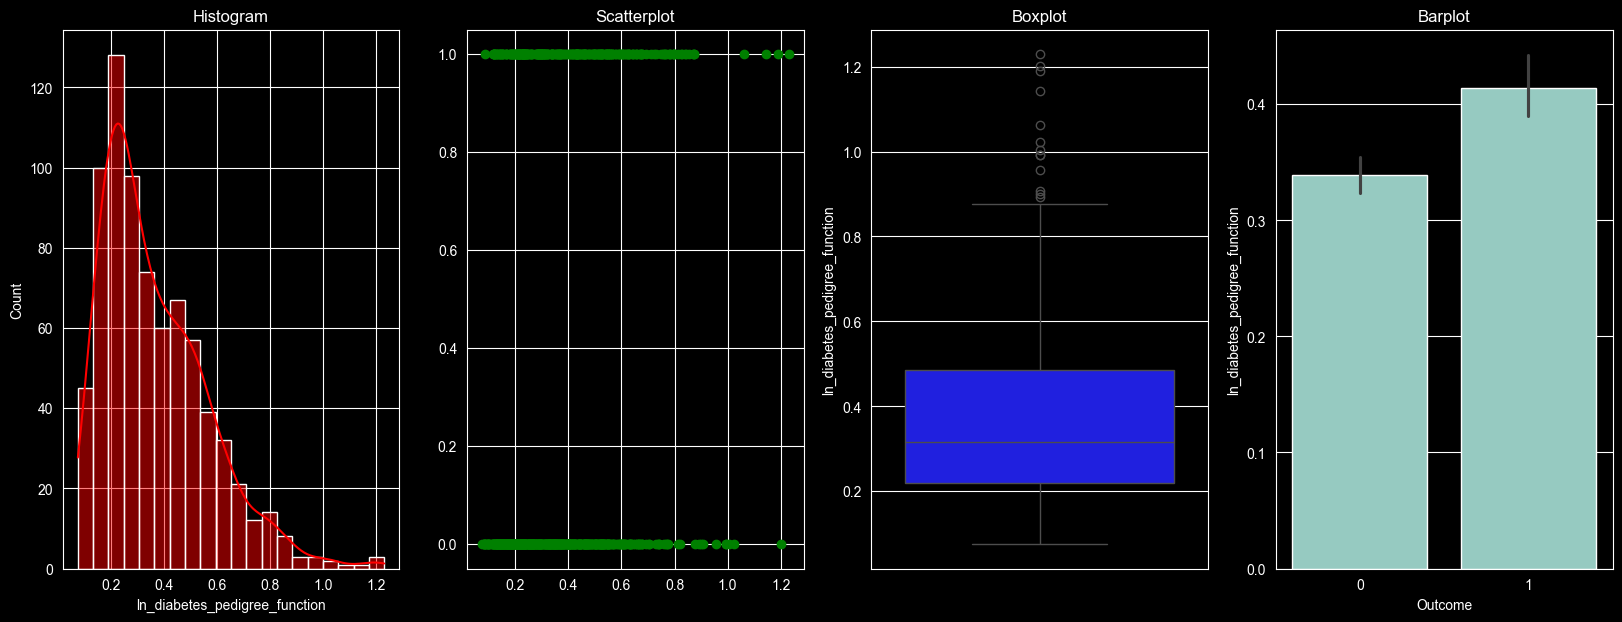

In [14]:
for column in modified_data.columns:
  diagnostic_plots(modified_data, column, "Outcome", False)

In [15]:
# Saving preprocessed dataset.
final_dataset = modified_data[[
    "Outcome",
    "Pregnancies",
    #"ln_pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    #"ln_insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    #"ln_diabetes_pedigree_function",
    "Age",
    #"ln_age"
    ]]
final_dataset.head()

,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,6,148,72,35,30.5,33.6,0.627,50
1,0,1,85,66,29,30.5,26.6,0.351,31
2,1,8,183,64,23,30.5,23.3,0.672,32
3,0,1,89,66,23,94.0,28.1,0.167,21
4,1,0,137,40,35,168.0,43.1,2.288,33


In [16]:
train_df, test_df = train_test_split(
    final_dataset,
    test_size=0.3,
    random_state=SEED,
    stratify=final_dataset["Outcome"]
)

train_df.to_csv("diabetes_preprocessed_train_data.csv", index=False, float_format="%.6f")
test_df.to_csv("diabetes_preprocessed_test_data.csv", index=False, float_format="%.6f")

In [17]:
# 1. Define the continuous/count variables for the 130-US Hospitals dataset
# (We exclude one-hot encoded categorical variables, IDs, and the target variable)
continuous_cols: list[str] = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

# Calculate standard deviations strictly from the TRAINING set to avoid data leakage
train_stds: pandas.Series = train_df[continuous_cols].std()

# 2. Create a noisy copy of the test dataframe
test_df_noisy: pandas.DataFrame = test_df.copy()

# 3. Apply 10% standard Gaussian noise to the continuous test columns
for col in continuous_cols:
    noise: numpy.ndarray = numpy.random.normal(
        loc=0.0,
        scale=0.10 * train_stds[col], # 10% of the train standard deviation
        size=len(test_df_noisy)
    )

    # Add noise
    test_df_noisy[col]: numpy.ndarray = test_df_noisy[col] + noise

    # Clip to prevent negative values
    test_df_noisy[col]: numpy.ndarray = numpy.clip(test_df_noisy[col], a_min=0, a_max=None)

    # Round to appropriate precision
    if col in ['BMI', 'DiabetesPedigreeFunction']:
        # Keep as float, possibly round to a specific decimal place
        decimals: int = 3 if col == 'DiabetesPedigreeFunction' else 1
        test_df_noisy[col]: numpy.ndarray = test_df_noisy[col].round(decimals)
    else:
        # Round to integer
        test_df_noisy[col]: numpy.ndarray = test_df_noisy[col].round().astype(int)

test_df_noisy.to_csv("diabetes_preprocessed_test_noisy_data.csv", index=False)